# **Lecture 17: Partial Differential Equations (PDE) - Classification & FDM Concepts**
**Date:** Friday, 13-02-2026

**Unit:** 2 (Differential Equations)

**Topic:** Partial Differential Equations (PDE): Classification & Finite Difference Method concepts

---

## **1. Introduction to PDEs in Astrophysics**

In the previous lectures, we looked at Ordinary Differential Equations (ODEs) where the unknown function depends on only **one** independent variable (usually time, $t$).

However, the universe is multidimensional. When a physical quantity depends on multiple independent variables—like time $t$ and spatial coordinates $x, y, z$—we use **Partial Differential Equations (PDEs)**.

**Astrophysical Examples:**
* **Stellar Structure:** How pressure, density, and temperature vary with radius $r$.
* **Fluid Dynamics (Hydrodynamics):** How gas in a nebula moves through 3D space over time.
* **Radiative Transfer:** How photons diffuse out of a star's core.
* **Gravitational Potential:** Poisson's equation relating mass density to the gravitational field.

## **2. Classification of 2nd-Order Linear PDEs**

Most fundamental physics equations are second-order linear PDEs. For a function $u(x, y)$ depending on two variables, the general form is:

$$A \frac{\partial^2 u}{\partial x^2} + B \frac{\partial^2 u}{\partial x \partial y} + C \frac{\partial^2 u}{\partial y^2} + D \frac{\partial u}{\partial x} + E \frac{\partial u}{\partial y} + F u = G$$

We classify them using the **discriminant** ($\Delta = B^2 - 4AC$), similar to conic sections in geometry. The classification tells us how information propagates through the system and dictates which numerical methods will be stable.

### **2.1 Elliptic PDEs ($B^2 - 4AC < 0$)**
* **Physical Meaning:** Steady-state or equilibrium problems (no time dependence). Information propagates instantly across the entire domain.
* **Example:** Laplace's Equation $\nabla^2 \Phi = 0$ or Poisson's Equation $\nabla^2 \Phi = 4\pi G \rho$ (Gravitational potential).
* **Numerical approach:** Solved as a giant system of simultaneous algebraic equations (Boundary Value Problem).

### **2.2 Parabolic PDEs ($B^2 - 4AC = 0$)**
* **Physical Meaning:** Diffusion processes smoothing out over time. Information propagates infinitely fast but decays exponentially.
* **Example:** The Heat Equation $\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}$ (Stellar cooling, photon diffusion).
* **Numerical approach:** "Marching" forward in time from initial conditions.

### **2.3 Hyperbolic PDEs ($B^2 - 4AC > 0$)**
* **Physical Meaning:** Wave propagation. Information travels at a finite speed (e.g., the speed of light or sound).
* **Example:** The Wave Equation $\frac{\partial^2 u}{\partial t^2} = c^2 \frac{\partial^2 u}{\partial x^2}$ (Gravitational waves, acoustic waves in stars).
* **Numerical approach:** "Marching" in time, but strictly constrained by the wave speed (requires stability checks like the CFL condition, which we cover in Lecture 20).

## **3. Discretizing the Universe: The Finite Difference Method (FDM)**

Computers cannot understand continuous space. We must trap our physics inside a discrete cage called a **Grid** or **Mesh**.

Imagine a 1D slice of a star.
* We divide Space $x$ into nodes: $x_i = i \Delta x$
* We divide Time $t$ into steps: $t_n = n \Delta t$

We denote the temperature $u$ at a specific place and time as:
$$u(x_i, t_n) \equiv u_i^n$$

### **3.1 Deriving FDM from First Principles (Taylor Series)**
How do we calculate the derivative $\frac{\partial u}{\partial x}$ on this grid? We use Taylor Series!

Let's expand the function slightly forward in space ($x_{i+1}$):
$$u_{i+1} = u_i + \Delta x \left(\frac{\partial u}{\partial x}\right)_i + \frac{\Delta x^2}{2} \left(\frac{\partial^2 u}{\partial x^2}\right)_i + O(\Delta x^3)$$

If we rearrange this to solve for the first derivative, we chop off (truncate) the higher-order terms. This gives us the **Forward Difference**:
$$\frac{\partial u}{\partial x} \approx \frac{u_{i+1} - u_i}{\Delta x} \quad \text{(Error is } O(\Delta x) \text{)}$$

### **3.2 The Power of the Central Difference**
Forward and Backward differences have a large truncation error. But look what happens if we subtract the backward Taylor expansion from the forward Taylor expansion:

$$u_{i+1} - u_{i-1} = 2 \Delta x \left(\frac{\partial u}{\partial x}\right)_i + O(\Delta x^3)$$

Solving for the derivative gives the **Central Difference**:
$$\frac{\partial u}{\partial x} \approx \frac{u_{i+1} - u_{i-1}}{2 \Delta x} \quad \text{(Error is } O(\Delta x^2) \text{)}$$

*Notice that the error is squared!* If we halve our grid spacing, the error drops by a factor of 4. This is the workhorse of computational astrophysics.

By adding the Taylor expansions instead of subtracting, we get the central difference for the **Second Derivative** (crucial for heat and wave equations):
$$\frac{\partial^2 u}{\partial x^2} \approx \frac{u_{i+1} - 2u_i + u_{i-1}}{(\Delta x)^2}$$

## **4. Python Example: Visualizing FDM Gradients**

Before we simulate a dying star, let's verify our math.
We will take a known mathematical profile, a Gaussian density pulse $u(x) = e^{-(x-5)^2/2}$, and use our discrete FDM formulas to calculate its spatial derivatives. We will then plot them against the exact analytical calculus derivatives to prove the grid works.

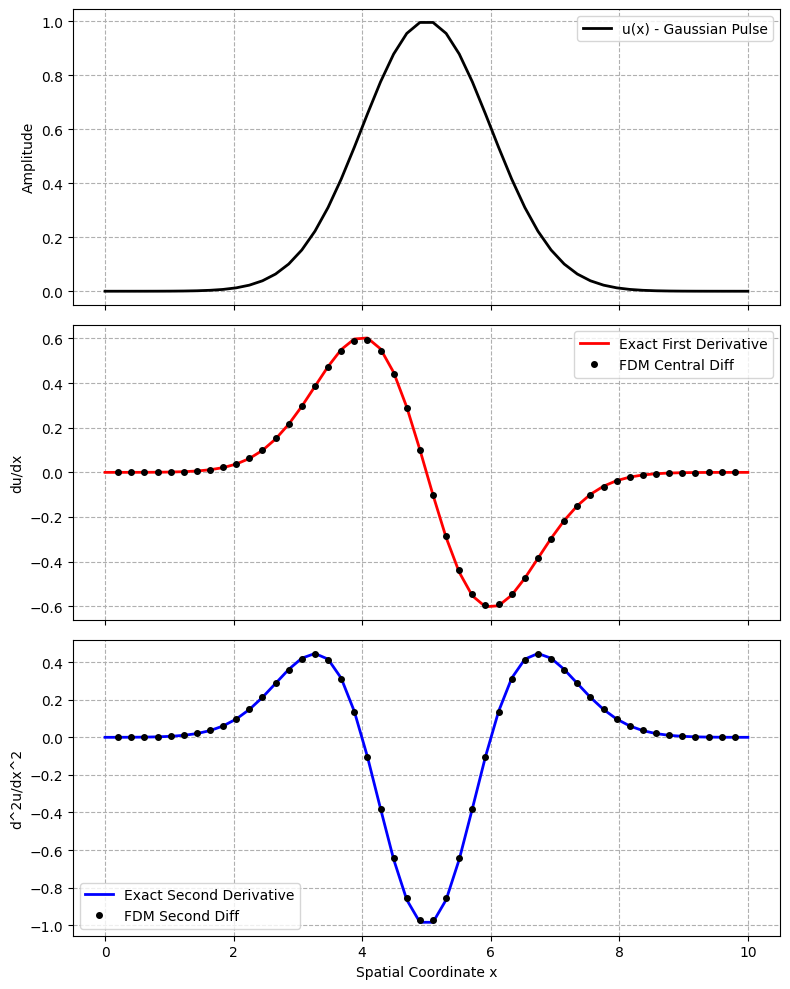

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup the spatial grid
L = 10.0          # Length of the domain
N = 50            # Number of grid points
x = np.linspace(0, L, N)
dx = x[1] - x[0]  # Grid spacing

# 2. Define a physical profile (e.g., a Gaussian density pulse)
u = np.exp(-0.5 * (x - 5.0)**2)

# Analytical derivatives for comparison
u_prime_exact = -(x - 5.0) * np.exp(-0.5 * (x - 5.0)**2)
u_double_prime_exact = ((x - 5.0)**2 - 1.0) * np.exp(-0.5 * (x - 5.0)**2)

# 3. Compute FDM First Derivative (Central Difference)
# Initialize array with zeros
du_dx = np.zeros(N)

# Loop over internal grid points (ignoring boundaries for a moment)
for i in range(1, N - 1):
    du_dx[i] = (u[i+1] - u[i-1]) / (2 * dx)

# 4. Compute FDM Second Derivative (Central Difference)
d2u_dx2 = np.zeros(N)
for i in range(1, N - 1):
    d2u_dx2[i] = (u[i+1] - 2*u[i] + u[i-1]) / (dx**2)

# 5. Plotting the Results
fig, axs = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# Function Plot
axs[0].plot(x, u, 'k-', lw=2, label='u(x) - Gaussian Pulse')
axs[0].set_ylabel('Amplitude')
axs[0].legend()
axs[0].grid(True, ls='--')

# First Derivative Plot
axs[1].plot(x, u_prime_exact, 'r-', lw=2, label='Exact First Derivative')
axs[1].plot(x[1:-1], du_dx[1:-1], 'ko', markersize=4, label='FDM Central Diff')
axs[1].set_ylabel('du/dx')
axs[1].legend()
axs[1].grid(True, ls='--')

# Second Derivative Plot
axs[2].plot(x, u_double_prime_exact, 'b-', lw=2, label='Exact Second Derivative')
axs[2].plot(x[1:-1], d2u_dx2[1:-1], 'ko', markersize=4, label='FDM Second Diff')
axs[2].set_xlabel('Spatial Coordinate x')
axs[2].set_ylabel('d^2u/dx^2')
axs[2].legend()
axs[2].grid(True, ls='--')

plt.tight_layout()
plt.show()


## **5. Student Exercises**

### **Problem 1: PDE Classification**
Look at the following governing equations used in astrophysics. Calculate the discriminant ($B^2 - 4AC$) for each and classify them as Elliptic, Parabolic, or Hyperbolic.

1.  **1D Acoustic Waves in a stellar interior:** $\frac{\partial^2 P}{\partial t^2} - c_s^2 \frac{\partial^2 P}{\partial x^2} = 0$ (where $P$ is pressure and $c_s$ is sound speed).
2.  **Steady-State Heat Conduction:** $\frac{\partial^2 T}{\partial x^2} + \frac{\partial^2 T}{\partial y^2} = 0$
3.  **Advection-Diffusion Equation (pollutant in a stellar wind):** $\frac{\partial C}{\partial t} + v \frac{\partial C}{\partial x} = D \frac{\partial^2 C}{\partial x^2}$

*Hint: For PDEs involving time $t$, treat $t$ as the $y$-variable in the general formula.*

---



## Solution 1: PDE Classification

A general second order PDE in two variables can be written as
$$
A \frac{\partial^2 u}{\partial x^2}
+ B \frac{\partial^2 u}{\partial x \partial y}
+ C \frac{\partial^2 u}{\partial y^2}
+ \text{(lower order terms)} = 0
$$

The classification depends on the **discriminant**
$$
D = B^2 - 4AC
$$

- $D > 0$ → **Hyperbolic**
- $D = 0$ → **Parabolic**
- $D < 0$ → **Elliptic**

For equations involving time $t$, treat $t$ as the second variable $y$.

---

### 1. 1D Acoustic Waves in a Stellar Interior
$$
\frac{\partial^2 P}{\partial t^2} - c_s^2 \frac{\partial^2 P}{\partial x^2} = 0
$$

Rewrite in the standard form:
$$
-c_s^2 \frac{\partial^2 P}{\partial x^2} + \frac{\partial^2 P}{\partial t^2} = 0
$$

Thus,
$$
A = -c_s^2, \qquad B = 0, \qquad C = 1
$$

Now compute the discriminant:
$$
B^2 - 4AC = 0^2 - 4(-c_s^2)(1)
$$
$$
= 4c_s^2
$$

Since
$$
4c_s^2 > 0
$$

the equation is **Hyperbolic**.

---

### 2. Steady-State Heat Conduction
$$
\frac{\partial^2 T}{\partial x^2} + \frac{\partial^2 T}{\partial y^2} = 0
$$

Comparing with the general form,
$$
A = 1, \qquad B = 0, \qquad C = 1
$$

Compute the discriminant:
$$
B^2 - 4AC = 0^2 - 4(1)(1)
$$
$$
= -4
$$

Since
$$
-4 < 0
$$

the equation is **Elliptic**.

---

### 3. Advection–Diffusion Equation
$$
\frac{\partial C}{\partial t} + v \frac{\partial C}{\partial x} = D \frac{\partial^2 C}{\partial x^2}
$$

Rearranging,
$$
D \frac{\partial^2 C}{\partial x^2}
- \frac{\partial C}{\partial t}
- v \frac{\partial C}{\partial x} = 0
$$

Only one second order derivative appears. Therefore
$$
A = D, \qquad B = 0, \qquad C = 0
$$

Compute the discriminant:
$$
B^2 - 4AC = 0^2 - 4(D)(0)
$$
$$
= 0
$$

Thus the equation is **Parabolic**.

---

### Final Classification

| Equation | A | B | C | $B^2 - 4AC$ | Type |
|---|---|---|---|---|---|
| Acoustic Wave Equation | $-c_s^2$ | 0 | 1 | $4c_s^2 > 0$ | Hyperbolic |
| Steady Heat Conduction | 1 | 0 | 1 | $-4 < 0$ | Elliptic |
| Advection–Diffusion | $D$ | 0 | 0 | 0 | Parabolic |

### **Problem 2: Matrix Formulation of the 2nd Derivative**
In practice, looping over arrays in Python (as we did in the code block above) is very slow for large simulations. Instead, we represent the Finite Difference operations as **Matrix Multiplications**.

The second derivative central difference formula is:
$u''_{i} \approx \frac{1}{\Delta x^2} (u_{i-1} - 2u_i + u_{i+1})$

If we have a grid of 5 internal points ($u_1, u_2, u_3, u_4, u_5$), we can write this as a matrix $A$ multiplying the vector $\vec{u}$:
$$\vec{u}'' = \frac{1}{\Delta x^2} A \vec{u}$$

**Task:**
1. Write down on paper what the $5 \times 5$ matrix $A$ looks like. (It will be a "tridiagonal" matrix).
2. Write a Python snippet below that constructs this tridiagonal matrix $A$ using `numpy.diag()`.

# Solution 2: Matrix Formulation of the Second Derivative

The finite difference approximation for the second derivative is
$$
u''_i \approx \frac{1}{\Delta x^2} (u_{i-1} - 2u_i + u_{i+1})
$$

For five internal grid points
$$
\vec{u} =
\begin{bmatrix}
u_1 \\
u_2 \\
u_3 \\
u_4 \\
u_5
\end{bmatrix}
$$

we can write
$$
\vec{u}'' = \frac{1}{\Delta x^2} A \vec{u}
$$

where $A$ is the **tridiagonal matrix**
$$
A =
\begin{bmatrix}
-2 & 1 & 0 & 0 & 0 \\
1 & -2 & 1 & 0 & 0 \\
0 & 1 & -2 & 1 & 0 \\
0 & 0 & 1 & -2 & 1 \\
0 & 0 & 0 & 1 & -2
\end{bmatrix}
$$

In [ ]:
# Student Code Area
import numpy as np

N_internal = 5
# Create the main diagonal (-2)
# Create the upper and lower diagonals (1)
# Combine them to form matrix A


In [ ]:
import numpy as np

N = 5

main_diag = -2 * np.ones(N)
upper_diag = np.ones(N-1)
lower_diag = np.ones(N-1)

A = np.diag(main_diag) + np.diag(upper_diag, 1) + np.diag(lower_diag, -1)

print(A)

[[-2.  1.  0.  0.  0.]
 [ 1. -2.  1.  0.  0.]
 [ 0.  1. -2.  1.  0.]
 [ 0.  0.  1. -2.  1.]
 [ 0.  0.  0.  1. -2.]]


Advanced Example: Vector Fields & Gravitational Gradients

Astrophysical Context: Instead of just 1D density pulses, let's look at 2D scalar fields. The gravitational potential $\Phi(x,y)$ of a binary star system is a scalar field. The gravitational acceleration (force per unit mass) is the negative gradient of this potential: $\vec{g} = -\nabla \Phi$. We will use FDM to calculate this vector field and visualize it.Pythonimport numpy as np


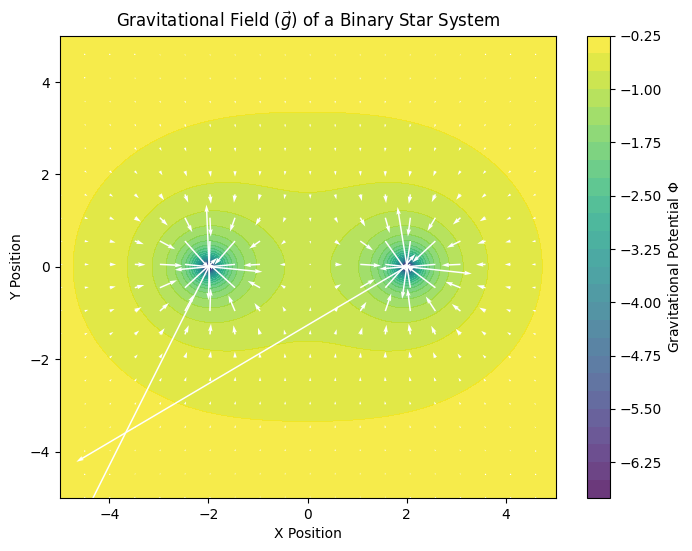

In [7]:
import matplotlib.pyplot as plt

# 1. Setup the 2D Space
grid_size = 100
x = np.linspace(-5, 5, grid_size)
y = np.linspace(-5, 5, grid_size)
X, Y = np.meshgrid(x, y)
dx = x[1] - x[0]
dy = y[1] - y[0]

# 2. Define the Scalar Field: Gravitational Potential of a Binary Star
# Phi = -GM/r. (Assuming G*M = 1 for simplicity)
# Star 1 at (-2, 0), Star 2 at (2, 0)
r1 = np.sqrt((X + 2)**2 + Y**2) + 0.1 # Add 0.1 to avoid division by zero at the singularity
r2 = np.sqrt((X - 2)**2 + Y**2) + 0.1
Phi = -(1.0 / r1) - (1.0 / r2)

# 3. Calculate the Gradient (First Derivatives) using FDM
# We can use numpy's built-in central difference gradient tool!
# Note: np.gradient returns (dPhi/dy, dPhi/dx) for 2D arrays due to row/col indexing
dPhi_dy, dPhi_dx = np.gradient(Phi, dy, dx)

# The gravitational field g = -Grad(Phi)
gx = -dPhi_dx
gy = -dPhi_dy

# 4. Visualization
plt.figure(figsize=(8, 6))

# Plot the scalar potential as background contours
plt.contourf(X, Y, Phi, levels=30, cmap='viridis', alpha=0.8)
plt.colorbar(label=r'Gravitational Potential $\Phi$')

# Plot the vector field using a quiver plot
# We slice the arrays [::5, ::5] to plot an arrow only every 5 grid points, preventing visual clutter
plt.quiver(X[::5, ::5], Y[::5, ::5], gx[::5, ::5], gy[::5, ::5],
           color='white', scale=20, width=0.003)

plt.title(r"Gravitational Field ($\vec{g}$) of a Binary Star System")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.show()


What students should learn: How a scalar field (Potential) relates to a vector field (Force) via spatial derivatives, and how to use np.gradient and plt.quiver for 2D FDM analysis.